# 카이제곱 검정(Chi-square test)

- 범주형 변수들 간의 연관성을 분석하기 위해 결합분포를 사용하는 방법
    - 연령 같은 변수는 연령대와 같은 서열척도로 변환해서 사용
 
- 기본 원리는 변수들 간의 범주를 동시에 교차하는 교차표를 만들어 각각의 빈도와 비율을 통해 변수 상호 간의 독립성과 관련성을 분석하는 것

- 교차분석은 상관분석과는 다르게 연관성의 정도를 수치로 표현 불가능
    - 대신 검정통계량 카이제곱을 통해 변수 간에 연관성이 없다는 귀무가설을 기각하는 지 여부로 상관성이 있고 없음을 판단

In [1]:
from scipy.stats import chi2_contingency
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# windows용 한글 폰트 오류 해결
from matplotlib import font_manager, rc
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc('font', family=font_name)

In [3]:
df = pd.read_csv("./data/csv/smoker.csv")

In [4]:
df.head()

,sex,smoke
0,male,Non-Smoker
1,male,Smoker
2,male,Non-Smoker
3,male,Smoker
4,male,Non-Smoker


In [5]:
# 항목별 집계
df.groupby(["sex", "smoke"])["smoke"].count()

sex     smoke     
female  Non-Smoker    50
        Smoker        12
male    Non-Smoker    40
        Smoker        29
Name: smoke, dtype: int64

- 여성은 62명 중 12명이 흡연자이고, 남성은 69명 중 29명이 흡연자

In [6]:
# 카이제곱 검정용 데이터셋 가공
crosstab = pd.crosstab(df["sex"], df["smoke"]) # 교차표 생성
crosstab

smoke,Non-Smoker,Smoker
sex,,
female,50,12
male,40,29


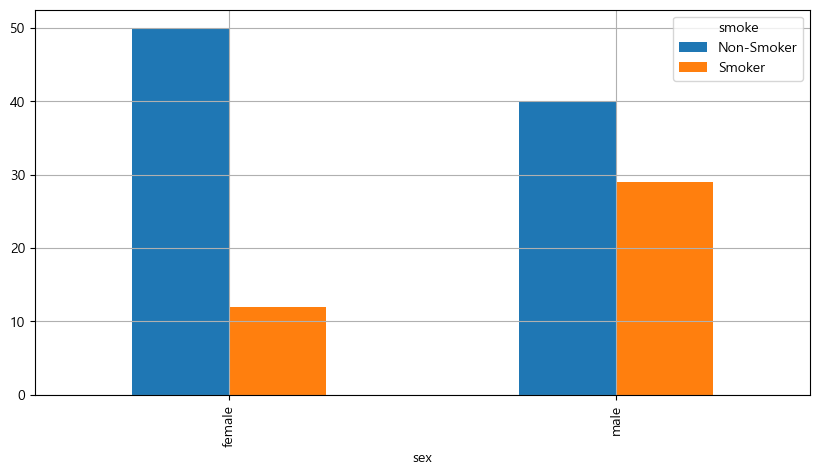

In [7]:
# 성별별 흡연자 수 시각화
crosstab.plot(kind = "bar", figsize = (10, 5))
plt.grid()

plt.show()

- 카이제곱 검정을 하기에 앞서 항목별 분포를 막대그래프로 시각화

- 눈으로 보기에도 남성과 여성의 흡연자 비율 차이가 크게 남
    - 이러한 차이가 통계적으로 유의미한 차이인지 확인하기 위해 카이제곱 검정 수행

In [8]:
# 카이제곱 검정
chi2_contingency(crosstab, correction = True)

Chi2ContingencyResult(statistic=np.float64(6.789242038107618), pvalue=np.float64(0.009170883871905303), dof=1, expected_freq=array([[42.59541985, 19.40458015],
       [47.40458015, 21.59541985]]))

In [9]:
chiresult = chi2_contingency(crosstab)

In [10]:
print(chiresult[0]) # 카이제곱 통계량

6.789242038107618


In [11]:
print(chiresult[1]) # p-value

0.009170883871905303
